Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 30, 30, 32)        896       
                                                                 
 conv2d_1 (Conv2D)           (None, 28, 28, 32)        9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 14, 14, 32)       0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 14, 14, 32)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 12, 12, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 10, 10, 64)        36928     
                                                        

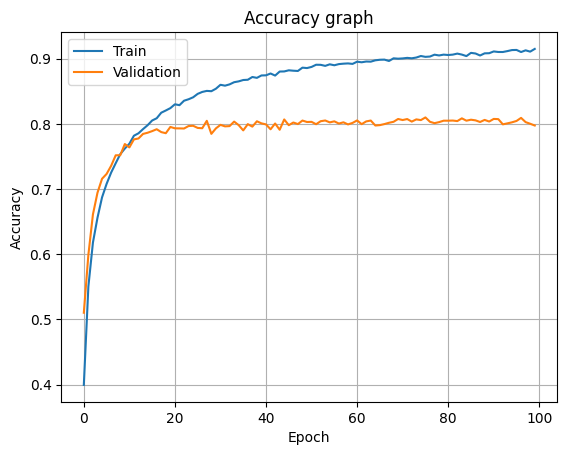

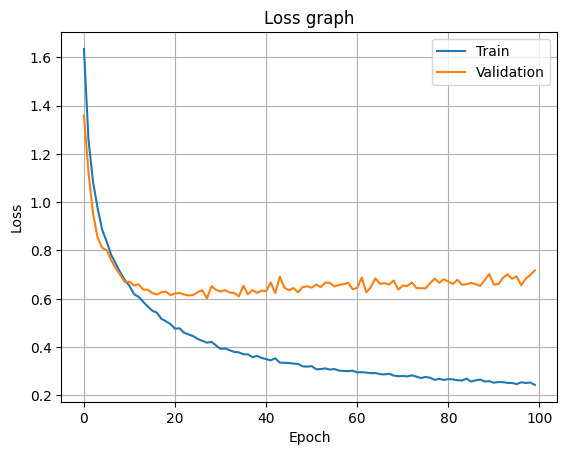

In [1]:
import numpy as np
import tensorflow as tf
import tensorflow.keras.datasets as ds

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# [1] CIFAR-10 데이터 불러오기
# x_train: 훈련 이미지 (50000, 32, 32, 3)
# y_train: 훈련 라벨 (50000, 1)
(x_train, y_train), (x_test, y_test) = ds.cifar10.load_data()

# [2] 이미지 정규화: 0~255 → 0~1로 스케일링
x_train = x_train.astype(np.float32) / 255.0
x_test = x_test.astype(np.float32) / 255.0

# [3] 레이블 One-hot 인코딩: 정수 → 벡터 (클래스 10개)
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# [4] CNN 모델 정의
cnn = Sequential()

# Conv 블록 1: Conv → Conv → Pooling → Dropout
cnn.add(Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
# - 32개의 3x3 필터로 기본 에지/패턴 추출
cnn.add(Conv2D(32, (3, 3), activation='relu'))
# - 더 깊은 특징 추출
cnn.add(MaxPooling2D(pool_size=(2, 2)))
# - 공간 크기 절반으로 축소
cnn.add(Dropout(0.25))
# - 과적합 방지: 일부 노드 랜덤 off

# Conv 블록 2: Conv → Conv → Pooling → Dropout
cnn.add(Conv2D(64, (3, 3), activation='relu'))
# - 더 많은 필터로 더 복잡한 패턴 학습
cnn.add(Conv2D(64, (3, 3), activation='relu'))
cnn.add(MaxPooling2D(pool_size=(2, 2)))
cnn.add(Dropout(0.25))

# 완전 연결층 준비: Flatten
cnn.add(Flatten())
# - 3D feature map → 1D 벡터로 변환

# Fully Connected: Dense → Dropout
cnn.add(Dense(units=512, activation='relu'))
# - 512개의 뉴런으로 특징 조합
cnn.add(Dropout(0.5))
# - FC 계층에서 과적합 방지

# 출력층: 10개 클래스 → softmax로 확률 출력
cnn.add(Dense(units=10, activation='softmax'))

cnn.summary()
# [5] 모델 컴파일
# - 다중 클래스 분류: categorical_crossentropy
# - Adam optimizer: learning_rate=0.001
cnn.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# [6] 모델 학습
# - batch_size=128, epochs=100
# - 검증 데이터: x_test, y_test
hist = cnn.fit(
    x_train, y_train,
    batch_size=128,
    epochs=100,
    validation_data=(x_test, y_test),
    verbose=2
)

# [7] 테스트 정확도 출력
res = cnn.evaluate(x_test, y_test, verbose=0)
print('정확률 =', res[1] * 100)

# [8] 정확도 그래프 출력
import matplotlib.pyplot as plt

plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Accuracy graph')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.grid()
plt.show()

# [9] 손실 그래프 출력
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Loss graph')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.grid()
plt.show()

#  Conv 블록 1 구조 분석 (예시)

##  Layer 요약

| Layer            | Output Shape        | Param  | 설명                    |
|------------------|---------------------|--------|-------------------------|
| **Conv2D**       | (None, 30, 30, 32)  | 896    | 3×3 필터로 기본 에지 추출 |
| **Conv2D_1**     | (None, 28, 28, 32)  | 9,248  | 더 깊은 특징 추출       |
| **MaxPooling2D** | (None, 14, 14, 32)  | 0      | 공간 크기 절반 축소     |

---

##  각 열의 의미

- **Layer**: 층의 이름과 타입 (예: Conv2D, MaxPooling2D 등)
- **Output Shape**: 층을 통과한 후 데이터의 형태 `(배치, 높이, 너비, 채널)`
  - `None`은 배치 크기(미정)
- **Param**: 학습할 파라미터 수 (가중치 + 바이어스)
  - Conv2D는 필터마다 가중치와 바이어스를 가짐
  - MaxPooling은 가중치가 없음 (계산만 수행)

---

##  출력 Shape 변화 흐름

1️**Conv2D (첫 번째)**  
- 입력: (32, 32, 3)  
- 필터: 32개, 커널: 3×3, padding: 'valid'  
- 계산: (32 - 3 + 1) = 30 → 출력 (30, 30, 32)

2️**Conv2D (두 번째)**  
- 입력: (30, 30, 32)  
- 필터: 32개, 커널: 3×3, padding: 'valid'  
- 계산: (30 - 3 + 1) = 28 → 출력 (28, 28, 32)

3️**MaxPooling2D**  
- 입력: (28, 28, 32)  
- 풀링: 2×2, stride 2 → (28/2, 28/2, 32) → 출력 (14, 14, 32)

---

## Param 계산 공식

> Conv2D 파라미터 수 = (커널 높이 × 커널 너비 × 입력 채널 수 + 바이어스 1개) × 출력 채널 수

예시:
- 첫 Conv2D  
  `(3×3×3 + 1) × 32 = (27 + 1) × 32 = 896`
- 두 번째 Conv2D  
  `(3×3×32 + 1) × 32 = (288 + 1) × 32 = 9,248`

---

## 핵심 요약

**Conv2D는 필터로 에지나 패턴을 추출하고 출력 크기를 줄이면서 학습 가능한 파라미터를 가짐.**  
**MaxPooling은 학습 파라미터는 없고, 특징맵의 공간 크기만 축소해 계산량과 과적합을 줄인다.**


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 32, 32, 3)]       0         
                                                                 
 conv2d_4 (Conv2D)           (None, 30, 30, 32)        896       
                                                                 
 conv2d_5 (Conv2D)           (None, 28, 28, 32)        9248      
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 14, 14, 32)       0         
 2D)                                                             
                                                                 
 dropout_3 (Dropout)         (None, 14, 14, 32)        0         
                                                                 
 conv2d_6 (Conv2D)           (None, 12, 12, 64)        18496     
                                                             

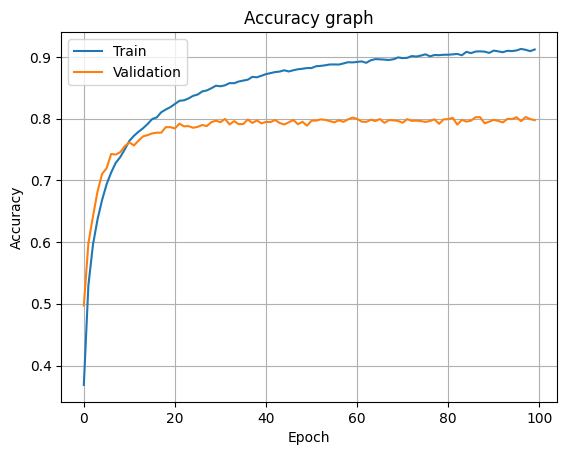

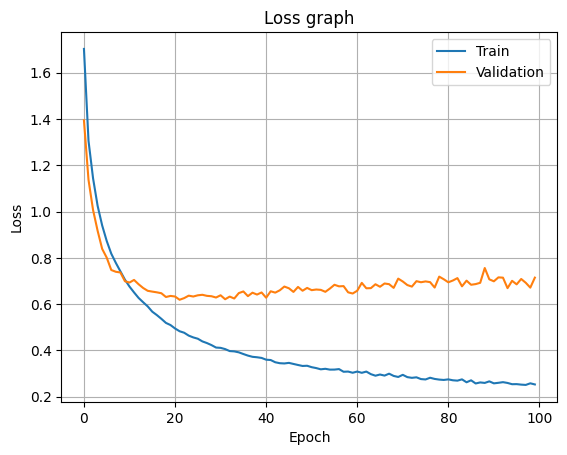

In [2]:
import numpy as np
import tensorflow as tf
import tensorflow.keras.datasets as ds
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
)
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# [1] 데이터셋 불러오기
(x_train, y_train), (x_test, y_test) = ds.cifar10.load_data()

# [2] 이미지 정규화
x_train = x_train.astype(np.float32) / 255.0
x_test = x_test.astype(np.float32) / 255.0

# [3] 레이블 One-hot 인코딩
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# [4] Functional API 입력층
inputs = Input(shape=(32, 32, 3))

# Conv 블록 1
x = Conv2D(32, (3, 3), activation='relu')(inputs)
x = Conv2D(32, (3, 3), activation='relu')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Dropout(0.25)(x)

# Conv 블록 2
x = Conv2D(64, (3, 3), activation='relu')(x)
x = Conv2D(64, (3, 3), activation='relu')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Dropout(0.25)(x)

# Flatten & Fully Connected
x = Flatten()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)

# 출력층: softmax로 10 클래스
outputs = Dense(10, activation='softmax')(x)

# 모델 정의
cnn = Model(inputs=inputs, outputs=outputs)

cnn.summary()

# [5] 컴파일
cnn.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# [6] 학습
hist = cnn.fit(
    x_train, y_train,
    batch_size=128,
    epochs=100,
    validation_data=(x_test, y_test),
    verbose=2
)

# [7] 테스트 정확도 출력
res = cnn.evaluate(x_test, y_test, verbose=0)
print('정확률 =', res[1] * 100)

# [8] 정확도 그래프 출력
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Accuracy graph')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.grid()
plt.show()

# [9] 손실 그래프 출력
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Loss graph')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.grid()
plt.show()


| 내용    | Sequential 버전             | Functional API 버전                           |
| ----- | ------------------------- | ------------------------------------------- |
| 모델 정의 | `cnn = Sequential([...])` | `inputs = Input() → Model(inputs, outputs)` |
| 층 연결  | `cnn.add(...)` 순차 연결      | 함수형으로 `(이전 출력)(입력)` 체인                      |
| 구조    | 동일                        | 동일                                          |
| 유연성   | 낮음                        | 높음 (다중 입력/출력 가능)                            |

Momentum = 0.0 정확률 = 89.41%
Momentum = 0.1 정확률 = 89.67%
Momentum = 0.2 정확률 = 90.18%
Momentum = 0.3 정확률 = 90.23%
Momentum = 0.4 정확률 = 90.58%
Momentum = 0.5 정확률 = 91.03%
Momentum = 0.6 정확률 = 91.28%
Momentum = 0.7 정확률 = 91.65%
Momentum = 0.8 정확률 = 92.12%
Momentum = 0.9 정확률 = 93.12%


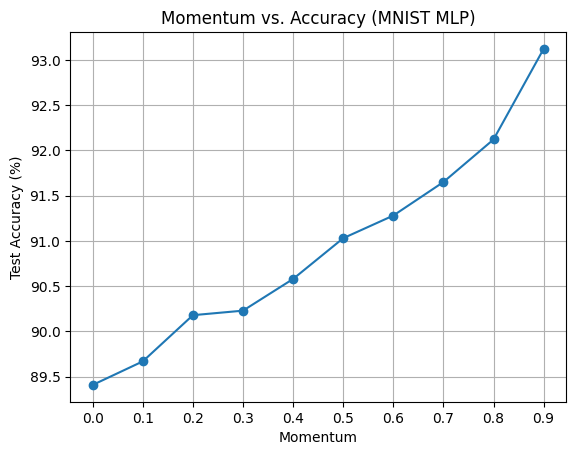

In [3]:
import numpy as np
import tensorflow as tf
import tensorflow.keras.datasets as ds
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

# [1] 데이터셋 로드
(x_train, y_train), (x_test, y_test) = ds.mnist.load_data()

# [2] 데이터 전처리
x_train = x_train.reshape(60000, 784).astype(np.float32) / 255.0
x_test = x_test.reshape(10000, 784).astype(np.float32) / 255.0

y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# [3] Momentum 값 범위 설정 (0.0 ~ 0.9)
momentum_values = np.arange(0.0, 1.0, 0.1)
accuracies = []

# [4] 각 모멘텀 값에 대해 모델을 학습하고 평가
for m in momentum_values:
    # MLP 모델 초기화
    mlp = Sequential()
    mlp.add(Dense(units=512, activation='tanh', input_shape=(784,)))
    mlp.add(Dense(units=10, activation='softmax'))
    
    # SGD 옵티마이저 설정 (모멘텀 적용)
    optimizer = SGD(learning_rate=0.01, momentum=m)
    
    # 모델 컴파일
    mlp.compile(loss='MSE',
                optimizer=optimizer,
                metrics=['accuracy'])
    
    # 모델 학습
    mlp.fit(x_train, y_train,
            batch_size=128,
            epochs=50,
            validation_data=(x_test, y_test),
            verbose=0)
    
    # 테스트 정확도 평가
    res = mlp.evaluate(x_test, y_test, verbose=0)
    accuracy = res[1] * 100
    accuracies.append(accuracy)
    
    print(f"Momentum = {m:.1f} 정확률 = {accuracy:.2f}%")

# [5] 모멘텀-정확도 그래프 출력
plt.plot(momentum_values, accuracies, marker='o')
plt.title('Momentum vs. Accuracy (MNIST MLP)')
plt.xlabel('Momentum')
plt.ylabel('Test Accuracy (%)')
plt.xticks(momentum_values)
plt.grid()
plt.show()


# 모멘텀(Momentum) 개념 정리

## 1) Momentum이란?

- 딥러닝 최적화에서 모멘텀(Momentum)은 **이전 단계의 기울기 방향을 일정 비율로 기억하여 관성을 가지듯 업데이트하는 방법**.

- v: 이전까지의 누적 기울기
- β: 모멘텀 계수 (0 ~ 1)
- α: 학습률(learning rate)

---

## 2) 왜 필요한가?

- SGD만 사용하면 손실 함수 지형이 복잡할 때 **좌우로 진동하며 느리게 수렴**할 수 있음.
- 모멘텀은 관성을 이용해 **작은 방해 요인에 흔들리지 않고 중요한 방향으로 꾸준히 나아감**.
- **좁고 긴 골짜기(ravine)** 형태의 손실 함수에서 더 큰 효과.

---

## 3) 물리학 직관

- **SGD만 쓴다:** 공이 경사면을 굴러가면서 작은 돌멩이에 부딪힐 때마다 이리저리 튀는 것과 비슷.
- **모멘텀을 쓴다:** 공에 관성이 있어 작은 방해물은 무시하고 큰 방향으로 더 빠르게 굴러감.

---

## 4) 모멘텀 값이 미치는 영향

| 모멘텀 값 | 특징 |
|-----------|------|
| 0.0 | 일반 SGD와 동일. 진동이 크고 수렴 속도가 느림 |
| 0.5 ~ 0.9 | 적당한 관성 유지. 진동 감소, 수렴 속도 향상 |
| 1.0 | 너무 크면 발산할 위험 있음 |

---

## 5) 실전 효과

- 진동 감소 → 최적점에 더 빨리 도달.
- 지역 최소값에서 더 좋은 값 찾을 확률 증가.
- 특히 **협곡 모양의 손실 지형**에서 빠르고 안정적인 학습 가능.

---

## 핵심 요약

> **Momentum은 과거의 관성을 기억해 최적점을 더 빠르고 안정적으로 찾아가도록 돕는 경사하강법 보조 기법**

---